In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import re
from sparrow import Protein

In [2]:
WTCRX = 'MMAYMNPGPHYSVNALALSGPSVDLMHQAVPYPSAPRKQRRERTTFTRSQLEELEALFAKTQYPDVYAREEVALKINLPESRVQVWFKNRRAKCRQQRQQQKQQQQPPGGQAKARPAKRKAGTSPRPSTDVCPDPLGISDSYSPPLPGPSGSPTTAVATVSIWSPASESPLPEAQRAGLVASGPSLTSAPYAMTYAPASAFCSSPSAYGSPSSYFSGLDPYLSPMVPQLGGPALSPLSGPSVGPSLAQSPTSLSGQSYGAYSPVDSLEFKDPTGTWKFTYNPMDPLDYKDQSAWKFQIL'

In [3]:
# Define window size
WINDOW_SIZE = 10

# Create protein object
protein = Protein(WTCRX)

# Calculate features in sliding windows
window_data = []

for i in range(len(WTCRX) - WINDOW_SIZE + 1):
    # Extract window sequence
    window_seq = WTCRX[i:i + WINDOW_SIZE]
    window_protein = Protein(window_seq)
    
    # Calculate features for this window
    window_data.append({
        'index': i,
        'window': f"{i+1}-{i+WINDOW_SIZE}",
        'f_positive': window_protein.fraction_positive,
        'f_negative': window_protein.fraction_negative,
        'hydrophobicity': window_protein.hydrophobicity,
        'FCR': window_protein.FCR,
        'NCPR': window_protein.NCPR,
        'aro': window_protein.fraction_aromatic,
        'ali': window_protein.fraction_aliphatic,
        'proline': window_protein.fraction_proline,
        'polar': window_protein.fraction_polar
    })

# Create DataFrame
df_windows = pd.DataFrame(window_data)

/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipykernel_59815/661660434.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


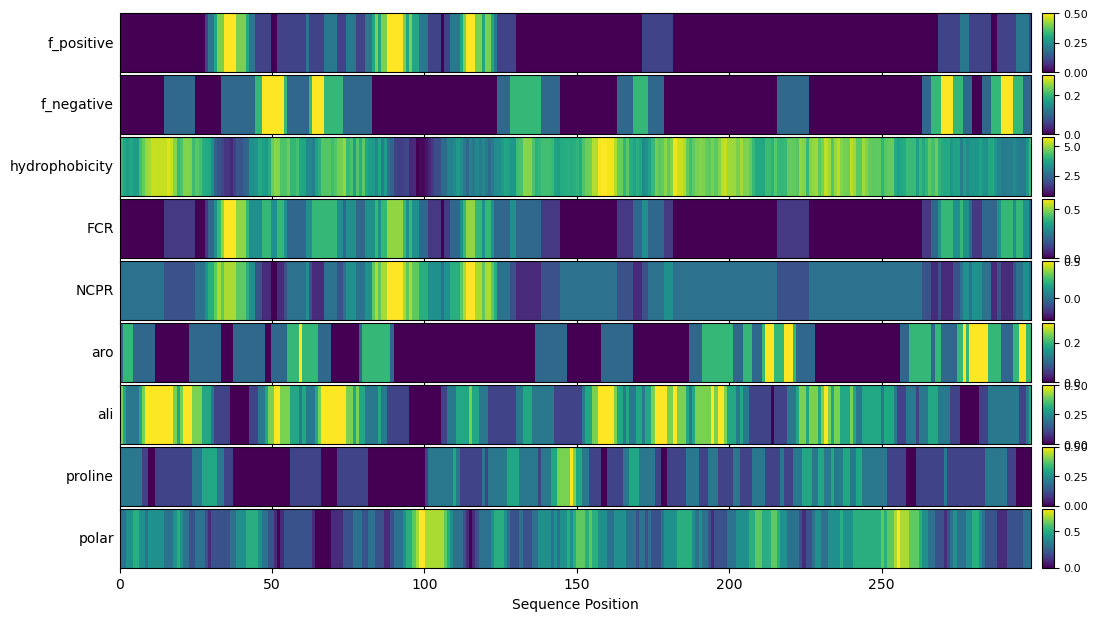

In [4]:
# Create figure with subplots - one for each metric
metrics = ['f_positive', 'f_negative', 'hydrophobicity', 'FCR', 'NCPR', 'aro', 'ali', 'proline', 'polar']

fig, axes = plt.subplots(len(metrics), 1, figsize=(14, len(metrics) * 0.8), 
                         gridspec_kw={'hspace': 0.05})

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    # Get values for this metric
    values = df_windows[metric].values
    
    # Reshape to 1 x n for heatmap
    data = values.reshape(1, -1)
    
    # Create heatmap
    im = ax.imshow(data, aspect='auto', cmap='viridis', 
                   vmin=values.min(), vmax=values.max(),
                   extent=[0, len(WTCRX), 0, 1])
    
    # Customize axes
    ax.set_xlim(0, len(WTCRX))
    ax.set_yticks([])
    ax.set_ylabel(metric, rotation=0, ha='right', va='center', fontsize=10)
    
    # Only show x-axis labels on bottom plot
    if i < len(metrics) - 1:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Sequence Position')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, pad=0.01, aspect=5)
    cbar.ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()